## Descripcion

Este cuaderno implementa el segundo acercamiento al reconocimiento de comandos de voz utilizando
**Multi-Instance Learning (MIL)** con **Random Forest como clasificador** y **espectrogramas de Mel
como instancias**. La idea central es tratar cada audio como una *bolsa de instancias*, donde cada
instancia es un frame temporal del espectrograma de Mel. El modelo clasifica frames individuales
y agrega esas predicciones por votacion para decidir la etiqueta final del audio completo.

Trabajaremos con las mismas **6 palabras clave** definidas inicialmente:
**Up, Down, Left, Right, Stop y Go**.

### Concepto de Multi-Instance Learning (MIL) con Espectrogramas

En el paradigma MIL cada muestra de entrenamiento es una *bolsa* que contiene multiples instancias.
Para audio con espectrogramas, esto se traduce en:

- **Bolsa:** un archivo de audio completo (1 segundo)
- **Instancia:** un frame temporal del espectrograma de Mel (vector de energias por banda de Mel)
- **Etiqueta:** la palabra pronunciada (up, down, left, right, stop, go)

El Random Forest clasifica cada instancia individualmente y luego se agrega por votacion para
obtener la prediccion final de la bolsa.

### Acercamiento

1. **Preprocesamiento**: VAD (Voice Activity Detection), normalizacion, padding a 1 segundo
2. **Extraccion de caracteristicas**: Espectrograma de Mel por cada frame -> instancias de la bolsa
3. **Aplanamiento MIL**: todas las instancias se apilan para entrenar el clasificador
4. **Entrenamiento Random Forest**: clasifica cada frame como instancia independiente
5. **Agregacion**: votacion por mayoria sobre los frames de cada audio
6. **Evaluacion**: metricas a nivel de bolsa (nivel audio)

### Importaciones

In [9]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import librosa
import librosa.display
import webrtcvad

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             precision_score, recall_score, f1_score)
from sklearn.decomposition import PCA

from collections import Counter
from tqdm import tqdm

print('Importaciones completadas exitosamente.')

Importaciones completadas exitosamente.


#### Configuraciones

Definimos las constantes que controlan el comportamiento del pipeline. Los valores de
`SAMPLE_RATE` y `TARGET_LENGTH` se ajustan a lo que confirmamos en la exploracion:
16000 Hz y 1 segundo exacto por muestra.

Para el espectrograma de Mel configuramos `N_MELS` bandas de frecuencia Mel y un `HOP_LENGTH`
que determina cuantos frames tendra cada bolsa.

In [10]:
DEST_FOLDER = 'speech_commands'
TARGET_WORDS = ['up', 'down', 'left', 'right', 'stop', 'go']


SAMPLE_RATE = 16000 # Hz, confirmado en la exploracion
TARGET_LENGTH = 16000 

# Parametros del espectrograma de Mel
N_MELS = 40 # Numero de bandas de Mel
N_FFT = 512 # Tamano de la ventana FFT
HOP_LENGTH = 256 # Desplazamiento entre ventanas

VAD_AGGRESSIVENESS = 2
FRAME_DURATION_MS = 30

# Parametros del Random Forest
N_ESTIMATORS = 200 # Numero de arboles
MAX_DEPTH = 20 # Profundidad maxima de cada arbol
MIN_SAMPLES_LEAF = 4 # Minimo de muestras por hoja
N_JOBS = -1 # Usar todos los cores disponibles

# --- Entrenamiento ---
RANDOM_STATE = 42

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print('Configuraciones establecidas:')
print(f'  - Palabras objetivo : {TARGET_WORDS}')
print(f'  - Sample Rate       : {SAMPLE_RATE} Hz')
print(f'  - Bandas Mel        : {N_MELS}')
print(f'  - VAD agresividad   : {VAD_AGGRESSIVENESS}')
print(f'  - RF estimadores    : {N_ESTIMATORS}, profundidad: {MAX_DEPTH}')

Configuraciones establecidas:
  - Palabras objetivo : ['up', 'down', 'left', 'right', 'stop', 'go']
  - Sample Rate       : 16000 Hz
  - Bandas Mel        : 40
  - VAD agresividad   : 2
  - RF estimadores    : 200, profundidad: 20


## Preprocesamiento de Audio

Antes de extraer caracteristicas necesitamos preparar cada audio. El pipeline tiene cuatro pasos:

1. **Carga**: leer el `.wav` y convertir a mono con la frecuencia de muestreo del dataset
2. **Normalizacion**: escalar la amplitud al rango `[-1, 1]` para uniformidad entre grabaciones
3. **VAD** *(Voice Activity Detection)*: recortar silencios usando WebRTC VAD;
   el silencio no aporta informacion discriminativa pero si ruido al modelo
4. **Padding / Truncamiento**: ajustar todos los audios a exactamente 1 segundo (16000 muestras)
   para garantizar bolsas del mismo tamano

In [11]:
def load_audio(filepath, sr=SAMPLE_RATE):
    try:
        audio, sr_loaded = librosa.load(filepath, sr=sr, mono=True)
        return audio, sr_loaded
    except Exception as e:
        print(f'Error al cargar {filepath}: {e}')
        return None, sr


def normalize_signal(audio):
    max_val = np.max(np.abs(audio))
    return audio / max_val if max_val > 0 else audio


def apply_vad(audio, sr=SAMPLE_RATE, aggressiveness=VAD_AGGRESSIVENESS, frame_duration_ms=FRAME_DURATION_MS):
    """
    Recorta silencios usando WebRTC VAD. Clasifica cada frame como voz/no-voz
    y descarta los frames silenciosos. Si el resultado queda por debajo de
    100ms (VAD fue demasiado agresivo) devuelve el audio original sin recortar.
    """
    if frame_duration_ms not in [10, 20, 30]:
        frame_duration_ms = 30

    audio_int16 = (audio * 32767).astype(np.int16)
    vad = webrtcvad.Vad(aggressiveness)
    frame_length = int(sr * frame_duration_ms / 1000)

    pad_length = frame_length - (len(audio_int16) % frame_length)
    if pad_length < frame_length:
        audio_int16 = np.pad(audio_int16, (0, pad_length), mode='constant')

    frames = [
        audio_int16[i:i + frame_length]
        for i in range(0, len(audio_int16), frame_length)
        if len(audio_int16[i:i + frame_length]) == frame_length
    ]
    if not frames:
        return audio

    is_speech = [vad.is_speech(frame.tobytes(), sr) for frame in frames]
    mask = np.repeat(is_speech, frame_length)[:len(audio)]
    trimmed = audio[mask]

    return trimmed if len(trimmed) >= sr * 0.1 else audio


def pad_or_truncate(audio, target_length=TARGET_LENGTH):
    if len(audio) > target_length:
        start = (len(audio) - target_length) // 2
        return audio[start:start + target_length]
    elif len(audio) < target_length:
        pad_left = (target_length - len(audio)) // 2
        pad_right = target_length - len(audio) - pad_left
        return np.pad(audio, (pad_left, pad_right), mode='constant')
    return audio


def preprocess_audio(filepath, sr=SAMPLE_RATE, apply_vad_flag=True, verbose=False):
    audio, _ = load_audio(filepath, sr=sr)
    if audio is None:
        return None

    audio = normalize_signal(audio)
    if apply_vad_flag:
        audio = apply_vad(audio, sr=sr)
    audio = pad_or_truncate(audio)

    if verbose:
        print(f'  Duracion final : {len(audio)/sr:.3f} s | Amplitud max: {np.max(np.abs(audio)):.4f}')

    return audio


print('Funciones de preprocesamiento definidas correctamente.')

Funciones de preprocesamiento definidas correctamente.


## Extraccion de Caracteristicas (Espectrograma de Mel)

El **espectrograma de Mel** representa la energia del audio en diferentes bandas de frecuencia
organizadas segun la escala de Mel (que aproxima la percepcion auditiva humana). Para cada
frame de tiempo obtenemos un vector de `N_MELS` valores que representan la energia en cada banda.

En terminos MIL:
- Cada **audio** es una **bolsa** -> array `(n_frames, N_MELS)`
- Cada **fila** es una **instancia** -> vector de energias Mel de un frame

A diferencia de los MFCCs (39 features con deltas), aqui cada instancia tiene `N_MELS` features
(40 por defecto), conservando mas informacion espectral directa.

In [12]:
def extract_mel_spectrogram(audio, sr=SAMPLE_RATE, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH):
    """
    Extrae el espectrograma de Mel y lo convierte a escala dB.
    Retorna array (n_frames, n_mels).
    """
    S = librosa.feature.melspectrogram(
        y=audio, sr=sr, n_mels=n_mels,
        n_fft=n_fft, hop_length=hop_length, center=False
    )
    # Convertir a dB para mejor separabilidad
    S_db = librosa.power_to_db(S, ref=np.max)
    return S_db.T  # (n_frames, n_mels)


def load_official_splits(base_path=DEST_FOLDER):
    """
    Carga las listas oficiales de validacion y test del dataset Google Speech Commands.
    Retorna dos sets con las rutas relativas de cada archivo.
    """
    val_path  = os.path.join(base_path, 'validation_list.txt')
    test_path = os.path.join(base_path, 'testing_list.txt')

    with open(val_path)  as f: val_files  = set(f.read().splitlines())
    with open(test_path) as f: test_files = set(f.read().splitlines())

    return val_files, test_files


def process_dataset_mil(base_path=DEST_FOLDER, target_words=TARGET_WORDS, max_files_per_class=None):
    """
    Recorre el dataset, preprocesa cada audio y extrae sus espectrogramas de Mel.
    Retorna (bags, labels, file_names, splits) donde cada bolsa es un array (n_frames, n_mels).
    splits indica 'train'/'val'/'test' segun la division oficial del dataset.
    """
    val_files, test_files = load_official_splits(base_path)
    bags, labels, file_names, splits = [], [], [], []

    for word in target_words:
        word_path = os.path.join(base_path, word)
        if not os.path.exists(word_path):
            print(f'Advertencia: no existe la carpeta {word_path}')
            continue

        files = [f for f in os.listdir(word_path) if f.endswith('.wav')]
        if max_files_per_class is not None:
            files = files[:max_files_per_class]

        print(f'Procesando clase "{word}": {len(files)} archivos...')

        for file_name in tqdm(files, desc=f'  {word}'):
            relative_path = f'{word}/{file_name}' # formato de las listas oficiales
            file_path = os.path.join(base_path, relative_path)

            audio = preprocess_audio(file_path)
            if audio is not None:
                bags.append(extract_mel_spectrogram(audio))
                labels.append(word)
                file_names.append(file_name)

                # Asignar split oficial
                if relative_path in val_files:
                    splits.append('val')
                elif relative_path in test_files:
                    splits.append('test')
                else:
                    splits.append('train')

    splits = np.array(splits)
    print(f'\nDataset procesado: {len(bags)} bolsas')
    print(f'  Train: {np.sum(splits=="train")} | Val: {np.sum(splits=="val")} | Test: {np.sum(splits=="test")}')
    print(f'Dimension de cada instancia: {bags[0].shape[1] if bags else "N/A"} features (bandas Mel)')
    return bags, labels, file_names, splits


print('Funciones de extraccion de caracteristicas definidas correctamente.')

Funciones de extraccion de caracteristicas definidas correctamente.


## Splits oficiales del dataset y preparación

In [13]:
def load_official_splits(base_path=DEST_FOLDER):
    val_path  = os.path.join(base_path, 'validation_list.txt')
    test_path = os.path.join(base_path, 'testing_list.txt')

    with open(val_path)  as f: val_files  = set(f.read().splitlines())
    with open(test_path) as f: test_files = set(f.read().splitlines())

    return val_files, test_files

def process_dataset_mil(base_path=DEST_FOLDER, target_words=TARGET_WORDS, max_files_per_class=None):
    val_files, test_files = load_official_splits(base_path)
    bags, labels, file_names, splits = [], [], [], []

    for word in target_words:
        word_path = os.path.join(base_path, word)
        if not os.path.exists(word_path):
            print(f'Advertencia: no existe la carpeta {word_path}')
            continue

        files = [f for f in os.listdir(word_path) if f.endswith('.wav')]
        if max_files_per_class is not None:
            files = files[:max_files_per_class]

        print(f'Procesando clase "{word}": {len(files)} archivos...')

        for file_name in tqdm(files, desc=f'  {word}'):
            relative_path = f'{word}/{file_name}'
            file_path = os.path.join(base_path, relative_path)

            audio = preprocess_audio(file_path)
            if audio is not None:
                bags.append(extract_mel_spectrogram(audio))
                labels.append(word)
                file_names.append(file_name)

                if relative_path in val_files:
                    splits.append('val')
                elif relative_path in test_files:
                    splits.append('test')
                else:
                    splits.append('train')

    splits = np.array(splits)
    print(f'\nDataset procesado: {len(bags)} bolsas')
    print(f'  Train: {np.sum(splits=="train")} | Val: {np.sum(splits=="val")} | Test: {np.sum(splits=="test")}')
    return bags, labels, file_names, splits

def prepare_mil_data(bags, labels):
    """
    Aplana las bolsas para alimentar al clasificador.
    Cada instancia hereda la etiqueta de su bolsa.
    Retorna (X_instances, y_instances, bag_indices).
    """
    X_instances, y_instances, bag_indices = [], [], []

    for bag_idx, (bag, label) in enumerate(zip(bags, labels)):
        n = len(bag)
        X_instances.append(bag)
        y_instances.extend([label] * n)
        bag_indices.extend([bag_idx] * n)

    X_instances = np.vstack(X_instances)
    y_instances = np.array(y_instances)
    bag_indices = np.array(bag_indices)

    return X_instances, y_instances, bag_indices

def aggregate_predictions(instance_predictions, bag_indices):
    aggregated = [
        Counter(instance_predictions[bag_indices == i]).most_common(1)[0][0]
        for i in np.unique(bag_indices)
    ]
    return np.array(aggregated)

print('Funciones MIL preparadas correctamente.')

Funciones MIL preparadas correctamente.


## Entrenamiento del Modelo

In [14]:
def train_mil_rf(X_instances, y_instances, bag_indices, bags, labels, splits):
    splits_np = np.array(splits)

    train_bag_idx = np.where(splits_np == 'train')[0]
    val_bag_idx = np.where(splits_np == 'val')[0]
    test_bag_idx = np.where(splits_np == 'test')[0]

    def get_mask(idx_set):
        return np.isin(bag_indices, idx_set)

    X_train = X_instances[get_mask(train_bag_idx)]
    y_train = y_instances[get_mask(train_bag_idx)]
    train_b = bag_indices[get_mask(train_bag_idx)]

    X_val = X_instances[get_mask(val_bag_idx)]
    val_b = bag_indices[get_mask(val_bag_idx)]

    X_test = X_instances[get_mask(test_bag_idx)]
    test_b = bag_indices[get_mask(test_bag_idx)]

    print('Normalizando features...')
    scaler  = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_val_sc = scaler.transform(X_val)
    X_test_sc = scaler.transform(X_test)

    print('Entrenando Random Forest...')
    model = RandomForestClassifier(
        n_estimators=N_ESTIMATORS, 
        max_depth=MAX_DEPTH, 
        min_samples_leaf=MIN_SAMPLES_LEAF, 
        n_jobs=N_JOBS, 
        random_state=RANDOM_STATE, 
        class_weight='balanced'
    )
    model.fit(X_train_sc, y_train)

    bag_labels_np = np.array(labels)

    return {
        'model'            : model,
        'scaler'           : scaler,
        'y_train_bag'      : bag_labels_np[train_bag_idx],
        'y_val_bag'        : bag_labels_np[val_bag_idx],
        'y_test_bag'       : bag_labels_np[test_bag_idx],
        'y_train_pred'     : aggregate_predictions(model.predict(X_train_sc), train_b),
        'y_val_pred'       : aggregate_predictions(model.predict(X_val_sc),   val_b),
        'y_test_pred'      : aggregate_predictions(model.predict(X_test_sc),  test_b),
        'train_bag_indices': train_bag_idx,
        'val_bag_indices'  : val_bag_idx,
        'test_bag_indices' : test_bag_idx,
    }

## Pipeline Principal

In [15]:
# Paso 1: Extraccion de espectrogramas de Mel
bags, labels, file_names, splits = process_dataset_mil(
    base_path=DEST_FOLDER,
    target_words=TARGET_WORDS,
    max_files_per_class=None
)

print(f'\nTotal de bolsas procesadas: {len(bags)}')
print(f'Distribucion de clases    : {Counter(labels)}')

Procesando clase "up": 3723 archivos...


  up: 100%|██████████| 3723/3723 [00:03<00:00, 942.53it/s]


Procesando clase "down": 3917 archivos...


  down: 100%|██████████| 3917/3917 [00:04<00:00, 952.80it/s]


Procesando clase "left": 3801 archivos...


...

Procesando clase "stop": 3872 archivos...


  stop: 100%|██████████| 3872/3872 [00:04<00:00, 945.75it/s]


Procesando clase "go": 3880 archivos...


  go: 100%|██████████| 3880/3880 [00:04<00:00, 909.36it/s]


Dataset procesado: 22971 bolsas
  Train: 18355 | Val: 2164 | Test: 2452

Total de bolsas procesadas: 22971
Distribucion de clases    : Counter({'down': 3917, 'go': 3880, 'stop': 3872, 'left': 3801, 'right': 3778, 'up': 3723})


In [16]:
# Paso 2: Aplanamiento para MIL
X_instances, y_instances, bag_indices = prepare_mil_data(bags, labels)

print(f'Dimensiones X_instances: {X_instances.shape}')
print(f'Etiquetas unicas       : {np.unique(y_instances)}')

Dimensiones X_instances: (1401231, 40)
Etiquetas unicas       : ['down' 'go' 'left' 'right' 'stop' 'up']


In [17]:
# Paso 3: Entrenamiento
results = train_mil_rf(X_instances, y_instances, bag_indices, bags, labels, splits)

print('\nEntrenamiento completado.')

Normalizando features...
Entrenando Random Forest...

Entrenamiento completado.



Evaluando el modelo en el conjunto de prueba...
Metricas de evaluacion (nivel de bolsa):
  Accuracy  : 0.4050
  Precision : 0.6556
  Recall    : 0.4050
  F1-Score  : 0.4004

Reporte por clase:
              precision    recall  f1-score   support

          up       0.66      0.44      0.53       406
        down       0.77      0.27      0.40       402
        left       0.68      0.47      0.56       412
       right       0.81      0.24      0.38       396
        stop       0.80      0.09      0.17       411
          go       0.24      0.89      0.37       425

    accuracy                           0.40      2452
   macro avg       0.66      0.40      0.40      2452
weighted avg       0.66      0.40      0.40      2452



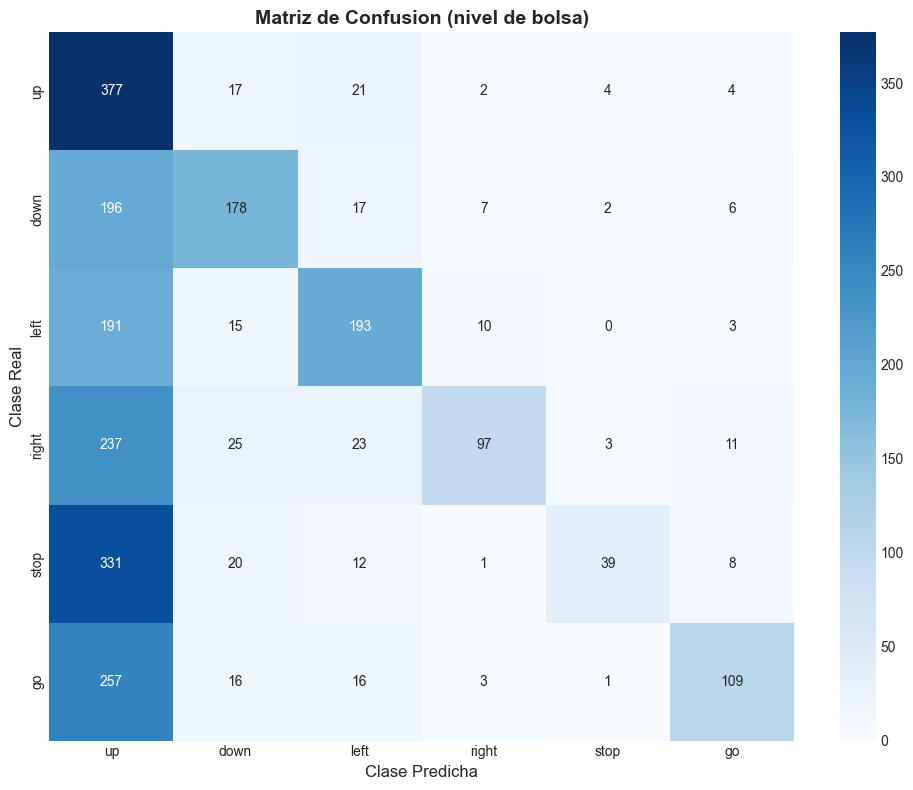


Evaluando el modelo en el conjunto de validación...
Metricas de evaluacion (nivel de bolsa):
  Accuracy  : 0.3831
  Precision : 0.6484
  Recall    : 0.3831
  F1-Score  : 0.3809

Reporte por clase:
              precision    recall  f1-score   support

          up       0.61      0.46      0.52       377
        down       0.74      0.26      0.39       372
        left       0.73      0.40      0.51       352
       right       0.85      0.18      0.30       363
        stop       0.74      0.11      0.20       350
          go       0.22      0.89      0.35       350

    accuracy                           0.38      2164
   macro avg       0.65      0.38      0.38      2164
weighted avg       0.65      0.38      0.38      2164



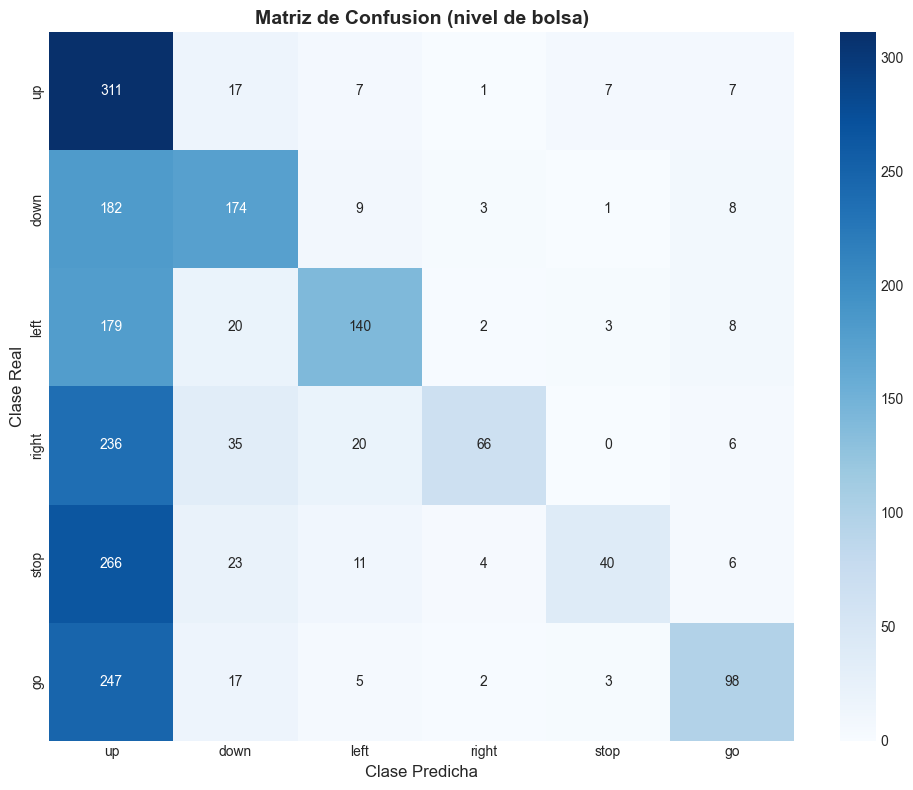

In [18]:
def evaluate_model(results, target_names=TARGET_WORDS):
    y_test_bag = results['y_test_bag']
    y_test_pred = results['y_test_pred']

    acc = accuracy_score(y_test_bag, y_test_pred)
    prec = precision_score(y_test_bag, y_test_pred, average='weighted')
    rec = recall_score(y_test_bag, y_test_pred, average='weighted')
    f1 = f1_score(y_test_bag, y_test_pred, average='weighted')

    print('Metricas de evaluacion (nivel de bolsa):')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1-Score  : {f1:.4f}')

    print('\nReporte por clase:')
    print(classification_report(y_test_bag, y_test_pred, target_names=target_names))

    cm = confusion_matrix(y_test_bag, y_test_pred, labels=target_names)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
    plt.title('Matriz de Confusion (nivel de bolsa)', fontsize=14, fontweight='bold')
    plt.ylabel('Clase Real', fontsize=12)
    plt.xlabel('Clase Predicha', fontsize=12)
    plt.tight_layout()
    plt.show()

    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1, 'confusion_matrix': cm}

print('\nEvaluando el modelo en el conjunto de prueba...')
metrics = evaluate_model(results, target_names=TARGET_WORDS)

print('\nEvaluando el modelo en el conjunto de validación...')
metrics_val = evaluate_model(
    {
        'y_test_bag' : results['y_val_bag'],
        'y_test_pred': results['y_val_pred'],
    },
    target_names=TARGET_WORDS
)